In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax import grad, jit, vmap, lax

PROJECT_ROOT = Path("..").resolve()
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

np.random.seed(0)

print("Project root:", PROJECT_ROOT)
print("Figure directory:", FIGURE_DIR)
print("JAX version:", jax.__version__)

Project root: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining
Figure directory: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures
JAX version: 0.6.2


## `jax.grad`

In [4]:
def scalar_loss(w):
    return (w - 3.0) ** 2


scalar_grad = grad(scalar_loss)

w_value = 0.0

print("scalar_loss(0):", scalar_loss(w_value))
print("scalar_grad(0):", scalar_grad(w_value))

print("Expected gradient at w=0:")
print(2 * (w_value - 3.0))

scalar_loss(0): 9.0
scalar_grad(0): -6.0
Expected gradient at w=0:
-6.0


In [6]:
learning_rate = 0.1
num_steps = 60

w = 0.0

w_history = []
loss_history = []

for step in range(num_steps):
    loss_value = scalar_loss(w)
    grad_value = scalar_grad(w)

    w = w - learning_rate * grad_value

    w_history.append(w)
    loss_history.append(loss_value)

print("Final w:", w)
print("Final loss:", scalar_loss(w))

Final w: 2.9999955
Final loss: 2.0520474e-11


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp10_scalar_gradient_descent_loss.png


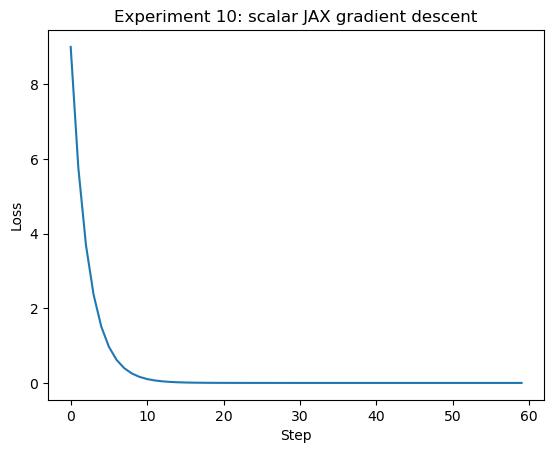

In [8]:
fig, ax = plt.subplots()

ax.plot(loss_history)

ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Experiment 10: scalar JAX gradient descent")

fig_path = FIGURE_DIR / "exp10_scalar_gradient_descent_loss.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

## Vector parameter MSE loss

In [10]:
N = 80
noise_std = 0.5

x_np = np.linspace(-3, 3, N)
epsilon_np = noise_std * np.random.randn(N)
y_np = 2.0 * x_np + 1.0 + epsilon_np

x = jnp.array(x_np)
y = jnp.array(y_np)

print("x_np shape:", x_np.shape)
print("y_np shape:", y_np.shape)
print("x shape:", x.shape)
print("y shape:", y.shape)

x_np shape: (80,)
y_np shape: (80,)
x shape: (80,)
y shape: (80,)


In [14]:
def predict_linear(params, x_values):
    """
    params shape: (2,)
    params[0] = w
    params[1] = b
    """
    w = params[0]
    b = params[1]

    return w * x_values + b


def mse_loss(params, x_values, y_values):
    y_pred = predict_linear(params, x_values)
    errors = y_pred - y_values
    return jnp.mean(errors ** 2)

In [16]:
params_initial = jnp.array([0.0, 0.0])

initial_loss = mse_loss(params_initial, x, y)

print("params_initial shape:", params_initial.shape)
print("initial_loss:", initial_loss)

params_initial shape: (2,)
initial_loss: 13.131891


In [18]:
mse_grad = grad(mse_loss)

grad_initial = mse_grad(params_initial, x, y)

print("grad_initial shape:", grad_initial.shape)
print("grad_initial:", grad_initial)

grad_initial shape: (2,)
grad_initial: [-11.964548  -2.237804]


## JAX gradient descent for linear regression

In [20]:
learning_rate = 0.05
num_steps = 500

params = jnp.array([0.0, 0.0])

params_history = []
loss_history = []

for step in range(num_steps):
    loss_value = mse_loss(params, x, y)
    grad_value = mse_grad(params, x, y)

    params = params - learning_rate * grad_value

    params_history.append(np.array(params))
    loss_history.append(float(loss_value))

params_history = np.array(params_history)

print("Final params:", params)
print("Estimated w:", params[0])
print("Estimated b:", params[1])
print("Final loss:", mse_loss(params, x, y))

Final params: [1.9448544 1.1189015]
Estimated w: 1.9448544
Estimated b: 1.1189015
Final loss: 0.24529631


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp10_jax_linear_regression_loss.png


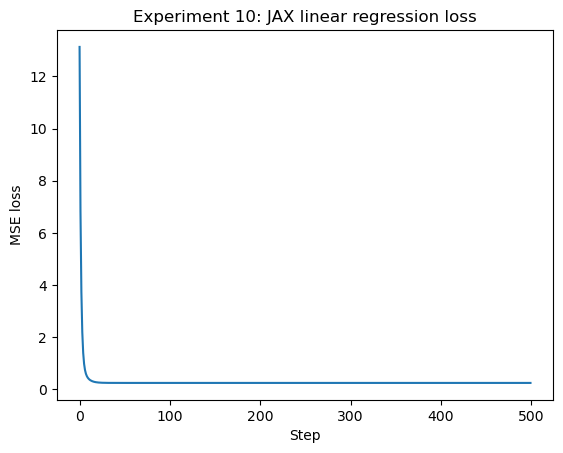

In [22]:
fig, ax = plt.subplots()

ax.plot(loss_history)

ax.set_xlabel("Step")
ax.set_ylabel("MSE loss")
ax.set_title("Experiment 10: JAX linear regression loss")

fig_path = FIGURE_DIR / "exp10_jax_linear_regression_loss.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp10_jax_parameter_trajectory.png


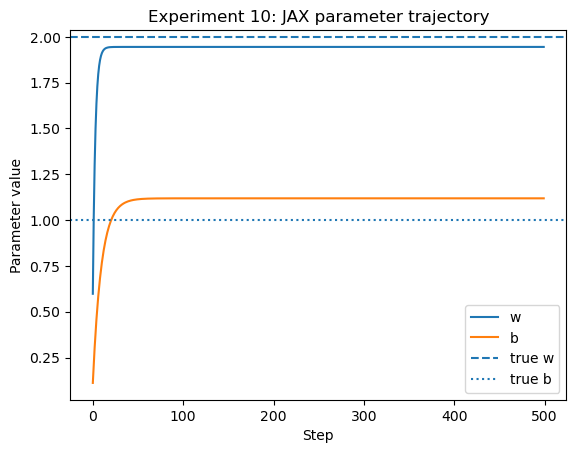

In [24]:
fig, ax = plt.subplots()

ax.plot(params_history[:, 0], label="w")
ax.plot(params_history[:, 1], label="b")

ax.axhline(2.0, linestyle="--", label="true w")
ax.axhline(1.0, linestyle=":", label="true b")

ax.set_xlabel("Step")
ax.set_ylabel("Parameter value")
ax.set_title("Experiment 10: JAX parameter trajectory")
ax.legend()

fig_path = FIGURE_DIR / "exp10_jax_parameter_trajectory.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

## Compare to NumPy least squares

In [26]:
Phi_np = np.column_stack([x_np, np.ones(N)])

theta_lstsq, residuals, rank, singular_values = np.linalg.lstsq(
    Phi_np,
    y_np,
    rcond=None
)

print("JAX gradient descent params:")
print(np.array(params))

print("\nNumPy least-squares params:")
print(theta_lstsq)

JAX gradient descent params:
[1.9448544 1.1189015]

NumPy least-squares params:
[1.94485454 1.11890199]


## `jax.jit`

In [28]:
@jit
def update_step(params, x_values, y_values, learning_rate):
    loss_value = mse_loss(params, x_values, y_values)
    grad_value = grad(mse_loss)(params, x_values, y_values)

    new_params = params - learning_rate * grad_value

    return new_params, loss_value

In [30]:
learning_rate = 0.05
num_steps = 500

params_jit = jnp.array([0.0, 0.0])

jit_loss_history = []

for step in range(num_steps):
    params_jit, loss_value = update_step(params_jit, x, y, learning_rate)
    jit_loss_history.append(float(loss_value))

print("params_jit:", params_jit)
print("Final JIT loss:", mse_loss(params_jit, x, y))

params_jit: [1.9448544 1.1189015]
Final JIT loss: 0.24529631


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp10_jit_update_loss.png


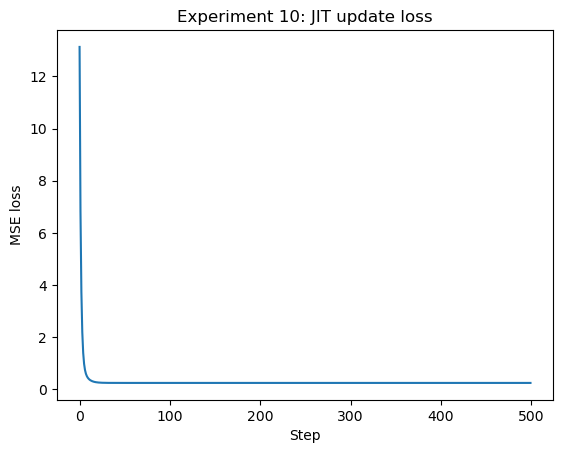

In [32]:
fig, ax = plt.subplots()

ax.plot(jit_loss_history)

ax.set_xlabel("Step")
ax.set_ylabel("MSE loss")
ax.set_title("Experiment 10: JIT update loss")

fig_path = FIGURE_DIR / "exp10_jit_update_loss.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

## `jax.vmap`

In [34]:
def predict_one(params, x_single):
    return params[0] * x_single + params[1]

In [36]:
predict_many = vmap(
    predict_one,
    in_axes=(None, 0)
)

y_pred_vmap = predict_many(params_jit, x)

print("params_jit shape:", params_jit.shape)
print("x shape:", x.shape)
print("y_pred_vmap shape:", y_pred_vmap.shape)

params_jit shape: (2,)
x shape: (80,)
y_pred_vmap shape: (80,)


In [45]:
y_pred_direct = predict_linear(params_jit, x)

max_difference = jnp.max(jnp.abs(y_pred_vmap - y_pred_direct))

print("Max difference between vmap prediction and direct prediction:")
print(max_difference)

Max difference between vmap prediction and direct prediction:
0.0


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp10_jax_linear_fit.png


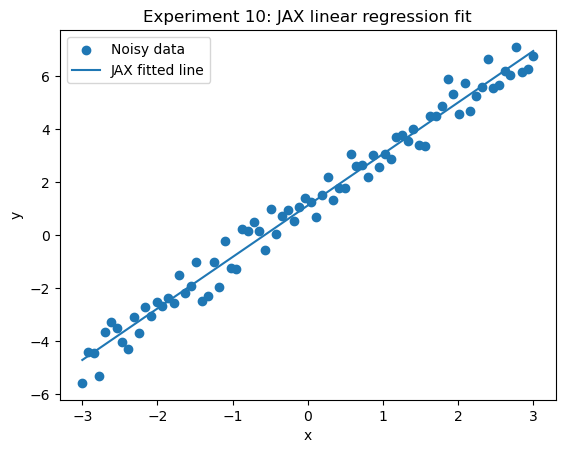

In [47]:
x_plot_np = np.linspace(-3, 3, 400)
x_plot = jnp.array(x_plot_np)

y_plot = predict_linear(params_jit, x_plot)

fig, ax = plt.subplots()

ax.scatter(x_np, y_np, label="Noisy data")
ax.plot(x_plot_np, np.array(y_plot), label="JAX fitted line")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Experiment 10: JAX linear regression fit")
ax.legend()

fig_path = FIGURE_DIR / "exp10_jax_linear_fit.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

## `jax.lax.scan` for rollout

In [49]:
dt = 0.05
k = 1.0
NUM_STEPS = 200


def oscillator_step(state, unused_input):
    """
    One oscillator step.

    state shape: (2,)
    returns:
        next_state shape: (2,)
        output shape: (2,)
    """
    q = state[0]
    v = state[1]

    q_next = q + v * dt
    v_next = v - k * q * dt

    next_state = jnp.array([q_next, v_next])

    return next_state, next_state

In [53]:
def rollout_scan(initial_state):
    """
    Roll out oscillator using lax.scan.

    initial_state shape: (2,)
    returned trajectory shape: (NUM_STEPS + 1, 2)
    """
    final_state, states_after_initial = lax.scan(
        oscillator_step,
        initial_state,
        xs=None,
        length=NUM_STEPS
    )

    trajectory = jnp.vstack([
        initial_state[None, :],
        states_after_initial
    ])

    return trajectory

In [55]:
initial_state = jnp.array([1.0, 0.0])

trajectory = rollout_scan(initial_state)

print("initial_state shape:", initial_state.shape)
print("trajectory shape:", trajectory.shape)
print("first 5 states:")
print(trajectory[:5])

initial_state shape: (2,)
trajectory shape: (201, 2)
first 5 states:
[[ 1.         0.       ]
 [ 1.        -0.05     ]
 [ 0.9975    -0.1      ]
 [ 0.9925    -0.149875 ]
 [ 0.9850063 -0.1995   ]]


In [57]:
rollout_scan_jit = jit(rollout_scan)

trajectory_jit = rollout_scan_jit(initial_state)

print("trajectory_jit shape:", trajectory_jit.shape)

trajectory_jit shape: (201, 2)


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp10_scan_rollout.png


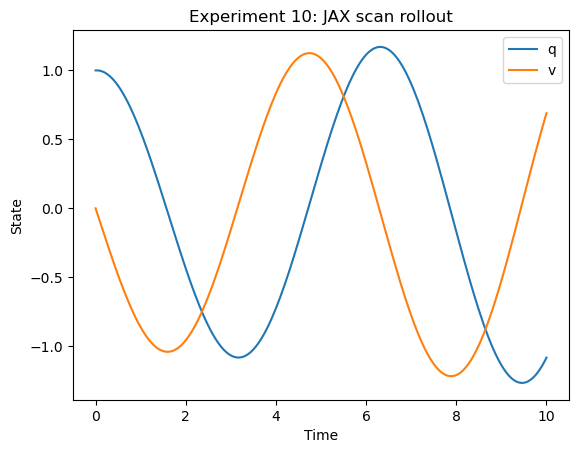

In [59]:
trajectory_np = np.array(trajectory_jit)
time = np.arange(NUM_STEPS + 1) * dt

fig, ax = plt.subplots()

ax.plot(time, trajectory_np[:, 0], label="q")
ax.plot(time, trajectory_np[:, 1], label="v")

ax.set_xlabel("Time")
ax.set_ylabel("State")
ax.set_title("Experiment 10: JAX scan rollout")
ax.legend()

fig_path = FIGURE_DIR / "exp10_scan_rollout.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

In [61]:
def rollout_with_k(k_value, initial_state):
    def step_with_k(state, unused_input):
        q = state[0]
        v = state[1]

        q_next = q + v * dt
        v_next = v - k_value * q * dt

        next_state = jnp.array([q_next, v_next])

        return next_state, next_state

    final_state, states_after_initial = lax.scan(
        step_with_k,
        initial_state,
        xs=None,
        length=NUM_STEPS
    )

    trajectory = jnp.vstack([
        initial_state[None, :],
        states_after_initial
    ])

    return trajectory


def final_position_loss(k_value):
    initial_state = jnp.array([1.0, 0.0])
    trajectory = rollout_with_k(k_value, initial_state)

    final_q = trajectory[-1, 0]

    return final_q ** 2


grad_final_position_loss = grad(final_position_loss)

k_value = 1.0

print("final_position_loss(k=1):", final_position_loss(k_value))
print("gradient d loss / d k at k=1:", grad_final_position_loss(k_value))

final_position_loss(k=1): 1.172513
gradient d loss / d k at k=1: -6.860873
